In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
 

In [77]:
#preparing data
train_df=pd.read_csv(r'C:\Users\ASUS\Downloads\space titanic\train.csv')
test_df=pd.read_csv(r'C:\Users\ASUS\Downloads\space titanic\test.csv')
train_df.head()
print(train_df['Destination'].value_counts())
print(train_df['HomePlanet'].value_counts())

Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64


In [78]:
#CHECKING DATA HEALTH
def data_health(df):
    print("Data Health Report")
    print("------------------")
    print(f"Total Rows: {df.shape[0]}")
    print(f"Total Columns: {df.shape[1]}")
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nData Types:")
    print(df.dtypes)
    print("\nStatistical Summary:")
    print(df.describe()) 
data_health(train_df)   

Data Health Report
------------------
Total Rows: 8693
Total Columns: 14

Missing Values:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

Data Types:
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

Statistical Summary:
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778  

In [79]:
#handling missing values
def handle_missing_values(df):
    df['Age'].fillna(df['Age'].median(), inplace=True)
    df['HomePlanet'].fillna(df['HomePlanet'].mode()[0], inplace=True)
    df['CryoSleep'].fillna(df['CryoSleep'].mode()[0], inplace=True)
    df['Cabin'].fillna('Unknown', inplace=True)
    df['Destination'].fillna(df['Destination'].mode()[0], inplace=True)
    df['VIP'].fillna(df['VIP'].mode()[0], inplace=True)
    df['FoodCourt'].fillna(df['FoodCourt'].median(), inplace=True)
    df['ShoppingMall'].fillna(df['ShoppingMall'].median(), inplace=True)
    df['Spa'].fillna(df['Spa'].median(), inplace=True)
    df['VRDeck'].fillna(df['VRDeck'].median(), inplace=True)
    return df
train_df=handle_missing_values(train_df)
test_df=handle_missing_values(test_df)
print("After handling missing values of data\n:")
data_health(train_df)
print("\n")
data_health(test_df)
train_df.head()


After handling missing values of data
:
Data Health Report
------------------
Total Rows: 8693
Total Columns: 14

Missing Values:
PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin             0
Destination       0
Age               0
VIP               0
RoomService     181
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
dtype: int64

Data Types:
PassengerId      object
HomePlanet       object
CryoSleep          bool
Cabin            object
Destination      object
Age             float64
VIP                bool
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

Statistical Summary:
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8693.000000   8512.000000   8693.000000   8693.000000   8693.000000   
mean     28.790291    224.687617    

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [80]:
#feature engineering
def feature_engineering(df):
    #drop unnecessary columns
    df.drop(columns=['Name','Cabin'],axis=1,inplace=True)
    
    #make columns with bool example:home_earth containing true if homeplanet is earth else false
    df['home_earth'] = df['HomePlanet'] == 'Earth'
    df['home_mars'] = df['HomePlanet'] == 'Mars'
    df['home_europa'] = df['HomePlanet'] == 'Europa'
    df['dest_TRAPPIST'] = df['Destination'] == 'TRAPPIST-1e'
    df['dest_Cancri'] = df['Destination'] == '55 Cancri e'
    df['dest_PSO'] = df['Destination'] == 'PSO J318.5-22'
    #drop unnecessary columns
    df.drop(columns=['HomePlanet','Destination'],axis=1,inplace=True)
    



    
    
    
    return df   
train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)
print("After feature engineering of data\n:")
train_df.head()

After feature engineering of data
:


,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,home_earth,home_mars,home_europa,dest_TRAPPIST,dest_Cancri,dest_PSO
0,0001_01,False,39.0,False,0.0,0.0,0.0,0.0,0.0,False,False,False,True,True,False,False
1,0002_01,False,24.0,False,109.0,9.0,25.0,549.0,44.0,True,True,False,False,True,False,False
2,0003_01,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,False,False,True,True,False,False
3,0003_02,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,False,False,True,True,False,False
4,0004_01,False,16.0,False,303.0,70.0,151.0,565.0,2.0,True,True,False,False,True,False,False


In [82]:
#encodeing categorical features
from sklearn.preprocessing import LabelEncoder 
le=LabelEncoder()
cat_cols=['CryoSleep','VIP','home_earth','home_mars','home_europa','dest_TRAPPIST','dest_Cancri','dest_PSO']
for col in cat_cols:
    train_df[col]=le.fit_transform(train_df[col])
    test_df[col]=le.fit_transform(test_df[col])
train_df['Transported']=le.fit_transform(train_df['Transported'])
train_df.head()



,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,home_earth,home_mars,home_europa,dest_TRAPPIST,dest_Cancri,dest_PSO
0,0001_01,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,1,0,0
1,0002_01,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,1,0,0,1,0,0
2,0003_01,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,0,0,1,1,0,0
3,0003_02,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,0,0,1,1,0,0
4,0004_01,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,1,0,0,1,0,0


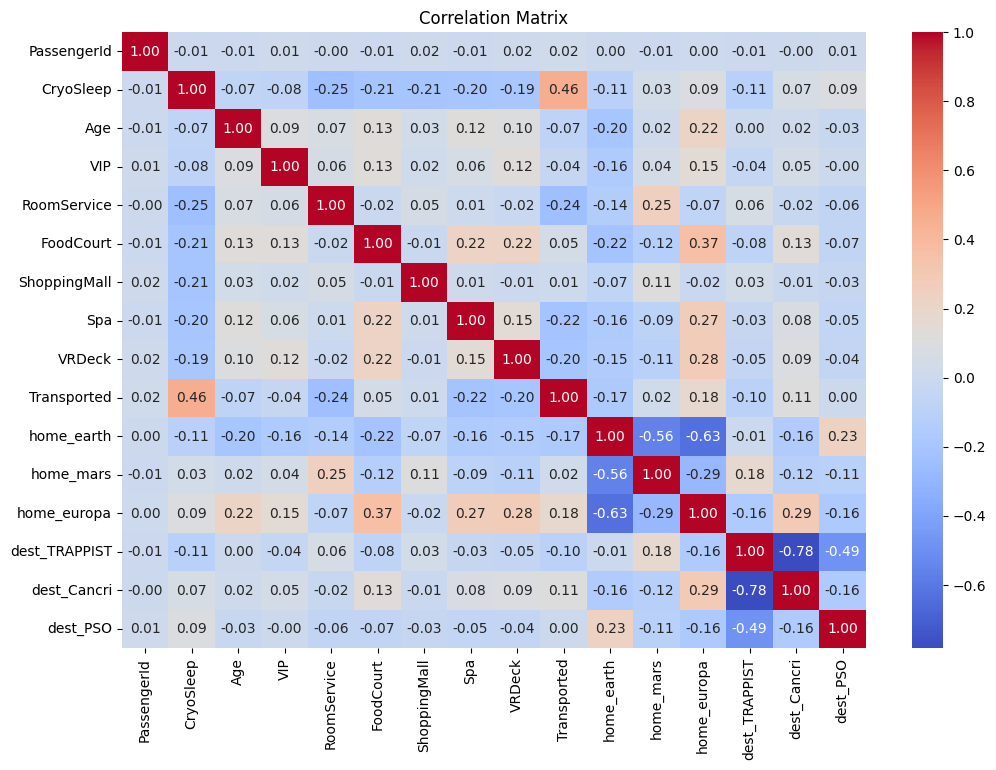

In [83]:
#correlation matrix on numerical features
plt.figure(figsize=(12,8))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

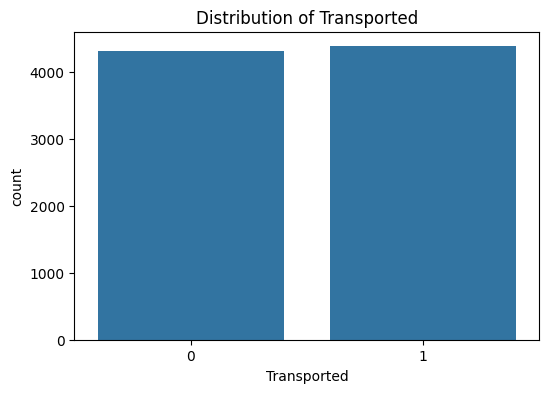

In [84]:
#plotting target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Transported', data=train_df)
plt.title("Distribution of Transported")
plt.show()

In [86]:
#preparing data for modeling
X=train_df.drop(columns=['Transported','PassengerId'],axis=1)
y=train_df['Transported']
#X_final_test for later
X_final_test=test_df.drop(columns=['PassengerId'],axis=1)

In [90]:
# lgbmodel
import lightgbm as lgb
import optuna as optuna
from optuna.integration import LightGBMPruningCallback
from sklearn.model_selection import train_test_split
#finding best hyperparameters using optuna
def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7)
    }
    #split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = lgb.LGBMClassifier(**param)
    model.fit(X_train, y_train)
    
    cv_results = lgb.cv(param, lgb.Dataset(X, label=y), nfold=5, stratified=True, seed=42,
                        callbacks=[LightGBMPruningCallback(trial, 'binary_logloss')])
    # robustly get the mean metric value (handles different LightGBM versions / key names)
    metric_key = None
    for k in cv_results.keys():
        if 'binary_logloss' in k and k.endswith('-mean'):
            metric_key = k
            break
    if metric_key is None:
        metric_key = list(cv_results.keys())[0]
    return cv_results[metric_key][-1]
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
best_params = study.best_params
print("Best Hyperparameters:", best_params)


[I 2025-12-28 10:32:22,631] A new study created in memory with name: no-name-21400af2-9486-497e-8a32-95e59b097d31


[LightGBM] [Warning] min_data_in_leaf is set=68, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=68
[LightGBM] [Warning] feature_fraction is set=0.6948531905093701, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6948531905093701
[LightGBM] [Warning] bagging_fraction is set=0.8035032560307307, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8035032560307307
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=68, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=68
[LightGBM] [Warning] feature_fraction is set=0.6948531905093701, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6948531905093701
[LightGBM] [Warning] bagging_fraction is set=0.8035032560307307, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8035032560307307
[LightGBM] [Warning] bagging_freq is set=6, su

[I 2025-12-28 10:32:23,068] Trial 0 finished with value: 0.43453123611050587 and parameters: {'learning_rate': 0.044013887261007946, 'num_leaves': 46, 'max_depth': 6, 'min_data_in_leaf': 68, 'feature_fraction': 0.6948531905093701, 'bagging_fraction': 0.8035032560307307, 'bagging_freq': 6}. Best is trial 0 with value: 0.43453123611050587.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-12-28 10:32:23,749] Trial 1 finished with value: 0.45643587804091956 and parameters: {'learning_rate': 0.20810190276731183, 'num_leaves': 137, 'max_depth': 10, 'min_data_in_leaf': 98, 'feature_fraction': 0.6790184097205045, 'bagging_fraction': 0.8870877913671209, 'bagging_freq': 3}. Best is trial 0 with value: 0.43453123611050587.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-12-28 10:32:34,770] Trial 48 pruned. Trial was pruned at iteration 29.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-12-28 10:32:34,862] Trial 49 pruned. Trial was pruned at iteration 0.


[LightGBM] [Info] Number of positive: 3502, number of negative: 3452
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1370
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 14
[LightGBM] [Info] Number of positive: 3502, number of negative: 3452
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000315 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1370
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 14
[LightGBM] [Info] Number of positive: 3502, number of negative: 3452
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.0

In [91]:
#training the model
#stratified k fold cross validation
from sklearn.model_selection import StratifiedKFold,cross_val_predict
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = lgb.LGBMClassifier(**best_params)
y_pred = cross_val_predict(model, X, y, cv=skf)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y, y_pred))
print("Classification Report:\n", classification_report(y, y_pred))

[LightGBM] [Warning] min_data_in_leaf is set=68, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=68
[LightGBM] [Warning] feature_fraction is set=0.6948531905093701, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6948531905093701
[LightGBM] [Warning] bagging_fraction is set=0.8035032560307307, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8035032560307307
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=68, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=68
[LightGBM] [Warning] feature_fraction is set=0.6948531905093701, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6948531905093701
[LightGBM] [Warning] bagging_fraction is set=0.8035032560307307, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8035032560307307
[LightGBM] [Warning] bagging_freq is set=6, su

In [ ]:
#testing on final test data
model.fit(X, y)
y_final_pred = model.predict(X_final_test)
#prepare submission file
submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': le.inverse_transform(y_final_pred)
})